
# Lab 8: Monte Carlo Markov Chain (MCMC)

## Modelo de Ising 2D

Como aplicación de la distribución canónica en `Física estadística` tenemos el modelo de **Ising**.

Para el caso de un material paramagnético de átomos de spin $1/2$ y momento magnetico $\mu_0$ en presencia de un campo magnético externo $H$, se ha determinado experimentalmente que la magnetización media depende del campo magnético y la temperatura del material. Consultar: (https://en.wikipedia.org/wiki/Ising_model)

**Exercise**: Considere un sistema compuesto por $N$ átomos no interactuantes en un material 2D, a una temperatura $T$ y en presencia de un campo magnético externo $H$ que está orientado en cierta dirección fija respecto al material:

<img src="https://upload.wikimedia.org/wikipedia/commons/f/fe/2D_ising_model_on_lattice.svg" width="550">

1. Realizar la simulación mediante el uso del método de Metrópolis Monte Carlo para este sistema. En este caso, visitar todos los
posibles spines de la red cristalina del material e intentear inversiones bajo condiciones adecuadas de energía y estabilidad del sistema:

    Algoritmo:
    * *Selecciona** un microestado $x$ inicial de manera aleatoria para todos los espines de la red (spin: +1 arriba y -1 abajo). Esta es la configuración inicial.
    * *Visitar* aleatoriamente un punto de la red y hacer una inversión de su espín... configuración $x'$.
    * *Aceptación*: Comprobar la energia $E$ del sistema.
            Si la energía disminuye se acepta la nueva configuración $x'$.
            Si aumenta, se debe generar un número aleatorio entre $[0,1]$. Si este número es mayor que el factor de Boltzman $\mathcal{P}(E,T)=e^{-E/(KT)}$ se rechaza $x'$. De lo contrario se acepta la nueva configuración $x'$.
    * *Repetir* los pasos anteriores.
    * *Finalizar*: Cuando llegue al creterio de finalización se debe terminar.


2. Graficar la Magnetización media del material vs el campo magnetico para tres temperaturas reducidas (H/T) con $T=\{5,15,20\}$ K (Kelvin) y un campo variable $-30\,G < H < +30\,G$ (Gauss), .  Monstrar que la distribución canónica de la magnetización clásica es muy acertada (consultar).
3. Investigar el resultado analítico para este sistema 2D y comparar con la simulación de MC. ¿Qué tan precisa es la simulación? Explique.

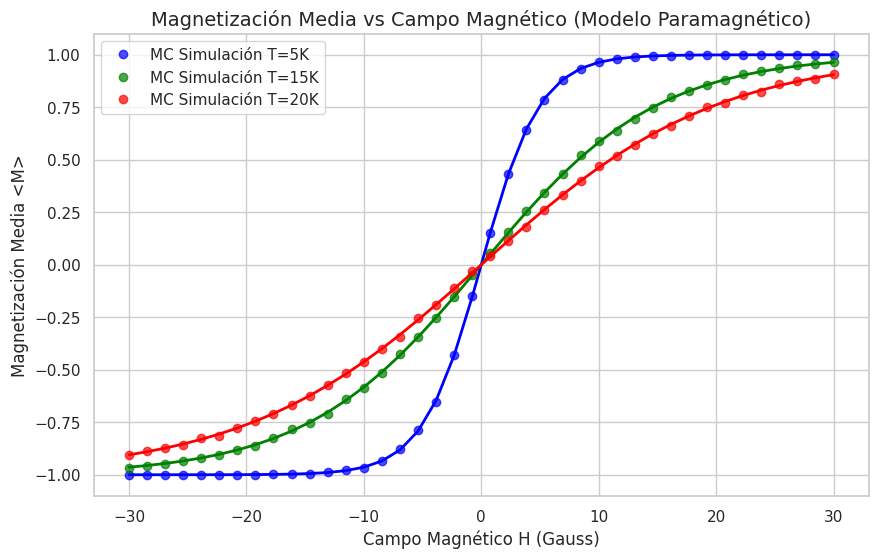

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")                # Configuración visual

def mcmc_paramagnet_2d(N_lado, T, H, N_Barridos=100):     #Nlado tamaño de la malla, T Temperatura en K y H campo magn

    N = N_lado * N_lado
    # 1. Estado inicial aleatorio (+1 o -1)
    spins = np.random.choice([-1, 1], size=(N_lado, N_lado))

    magnetizaciones = []

    # Un Barrido equivale a intentar cambiar N espines
    total_pasos = N_Barridos * N

    for paso in range(total_pasos):
        # Seleccionar un espín al azar
        i, j = np.random.randint(0, N_lado, size=2)
        s = spins[i, j]

        # Calcular el cambio de energía (en unidades reducidas mu_0 = 1, k_B = 1)
        dE = 2 * H * s

        # Criterio de Metropolis
        if dE <= 0:
            spins[i, j] = -s # Aceptación
        else:
            # Generar número aleatorio entre 0 y 1
            if np.random.rand() < np.exp(-dE / T):
                spins[i, j] = -s # Aceptación térmica

        # Medir la magnetización al final de cada barrido para evitar correlaciones fuertes entre medidas sucesivas
        if (paso + 1) % N == 0:
            magnetizaciones.append(np.mean(spins))

    # Descartamos el primer 30% de los datos (tiempo de termalización)
    terma_idx = int(0.3 * len(magnetizaciones))
    M_eq = magnetizaciones[terma_idx:]

    # Retornamos la magnetización media en el equilibrio
    return np.mean(M_eq)

# Ejecución para el Punto 2

N_lado = 20           # Malla de 20x20 (400 átomos)
T_valores = [5, 15, 20] # Temperaturas en Kelvin
H_valores = np.linspace(-30, 30, 40) # Campo de -30 a +30 Gauss

plt.figure(figsize=(10, 6))
colors = {5: 'blue', 15: 'green', 20: 'red'}

for T in T_valores:
    M_simulated = []
    M_analytical = []

    for H in H_valores:
        # 1. Dato Simulado con MCMC
        m_sim = mcmc_paramagnet_2d(N_lado, T, H, N_Barridos=150)
        M_simulated.append(m_sim)

        # 2. Dato Analítico Exacto
        m_ana = np.tanh(H / T)
        M_analytical.append(m_ana)

    # Graficar resultados de la simulación (puntos)
    plt.plot(H_valores, M_simulated, 'o', color=colors[T],
             label=f'MC Simulación T={T}K', alpha=0.7)

    # Graficar resultado analítico (línea continua)
    plt.plot(H_valores, M_analytical, '-', color=colors[T],
             linewidth=2)

plt.title('Magnetización Media vs Campo Magnético (Modelo Paramagnético)', fontsize=14)
plt.xlabel('Campo Magnético H (Gauss)', fontsize=12)
plt.ylabel('Magnetización Media <M>', fontsize=12)
plt.legend(loc='best')
plt.show()

El resultado analítico para un sistema de partículas de espín $1/2$ no interactuantes se obtiene mediante la suma de la función de partición canónica $Z$. Como los átomos no interactúan entre sí, la función de partición total es simplemente el producto de las funciones de partición individuales. Para un solo espín, los dos estados de energía posibles son $+H$ y $-H$. La función de partición individual es:
$$Z_1 = e^{H/T} + e^{-H/T} = 2 \cosh(H/T)$$

La magnetización media por espín $\langle M \rangle$ se calcula derivando el logaritmo de la función de partición respecto al campo:

$$\langle M \rangle = T \frac{\partial \ln(Z_1)}{\partial H} = \frac{e^{H/T} - e^{-H/T}}{e^{H/T} + e^{-H/T}}$$

$$\langle M \rangle = \tanh\left(\frac{H}{T}\right)$$

Se cuenta con una precision alta pero a temperaturas bajas (T=5 K), el sistema se satura rápidamente (todos los espines se alinean con H) mostrando la curva azul empinada.A temperaturas altas (T=20 K), la agitación térmica compite fuertemente contra el campo magnético, previniendo la alineación total de los espines a menos que H sea muy grande, resultando en una pendiente más suave (curva roja).

Nota: 4.5 (entrega tarde)

* En la magnetización haces kB = 1, magneton de Bhor =1..., pero al final debe recuperarse el valor en el MKS. La figura no corresponde a la que se pide en el enunciado, 
ya que no se ha recuperado el valor de kB.
* se dejó llevar con el error en el enunciado... 